# Lab Task
## CardioNet - Intelligent System for Heart Disease Prediction

In [92]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

### Data loading and exploration

In [93]:
# load dataset
df = pd.read_csv("heart.csv")
df.shape, df.dtypes

((1025, 14),
 age           int64
 sex           int64
 cp            int64
 trestbps      int64
 chol          int64
 fbs           int64
 restecg       int64
 thalach       int64
 exang         int64
 oldpeak     float64
 slope         int64
 ca            int64
 thal          int64
 target        int64
 dtype: object)

In [94]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [96]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [97]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### Data Visualization

In [98]:
# Features and Target Variable
x = df.drop('target', axis=1)
y = df['target']

In [99]:
x, y

(      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
 0      52    1   0       125   212    0        1      168      0      1.0   
 1      53    1   0       140   203    1        0      155      1      3.1   
 2      70    1   0       145   174    0        1      125      1      2.6   
 3      61    1   0       148   203    0        1      161      0      0.0   
 4      62    0   0       138   294    1        1      106      0      1.9   
 ...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
 1020   59    1   1       140   221    0        1      164      1      0.0   
 1021   60    1   0       125   258    0        0      141      1      2.8   
 1022   47    1   0       110   275    0        0      118      1      1.0   
 1023   50    0   0       110   254    0        0      159      0      0.0   
 1024   54    1   0       120   188    0        1      113      0      1.4   
 
       slope  ca  thal  
 0         2   2     3  
 1         0

In [ ]:
# distribution of target class

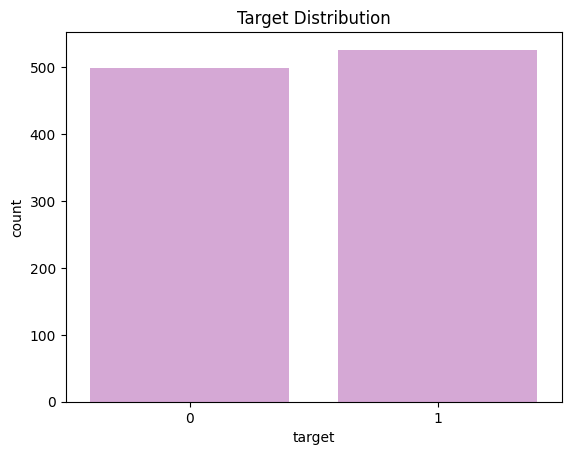

In [100]:
sns.countplot(x='target', data=df, color='plum')
plt.title("Target Distribution")
plt.show()

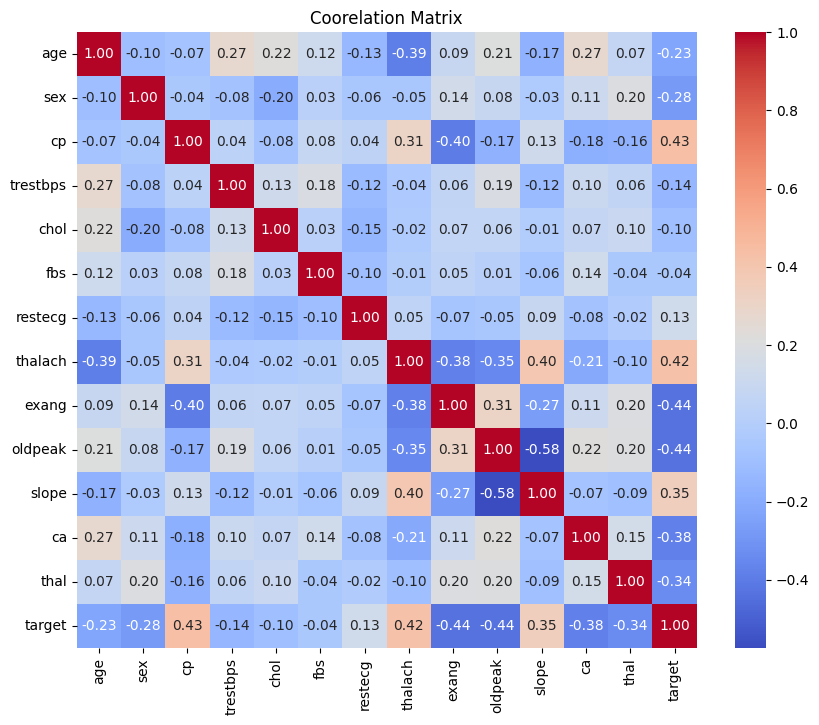

In [101]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 10})
plt.title("Coorelation Matrix")
plt.show()

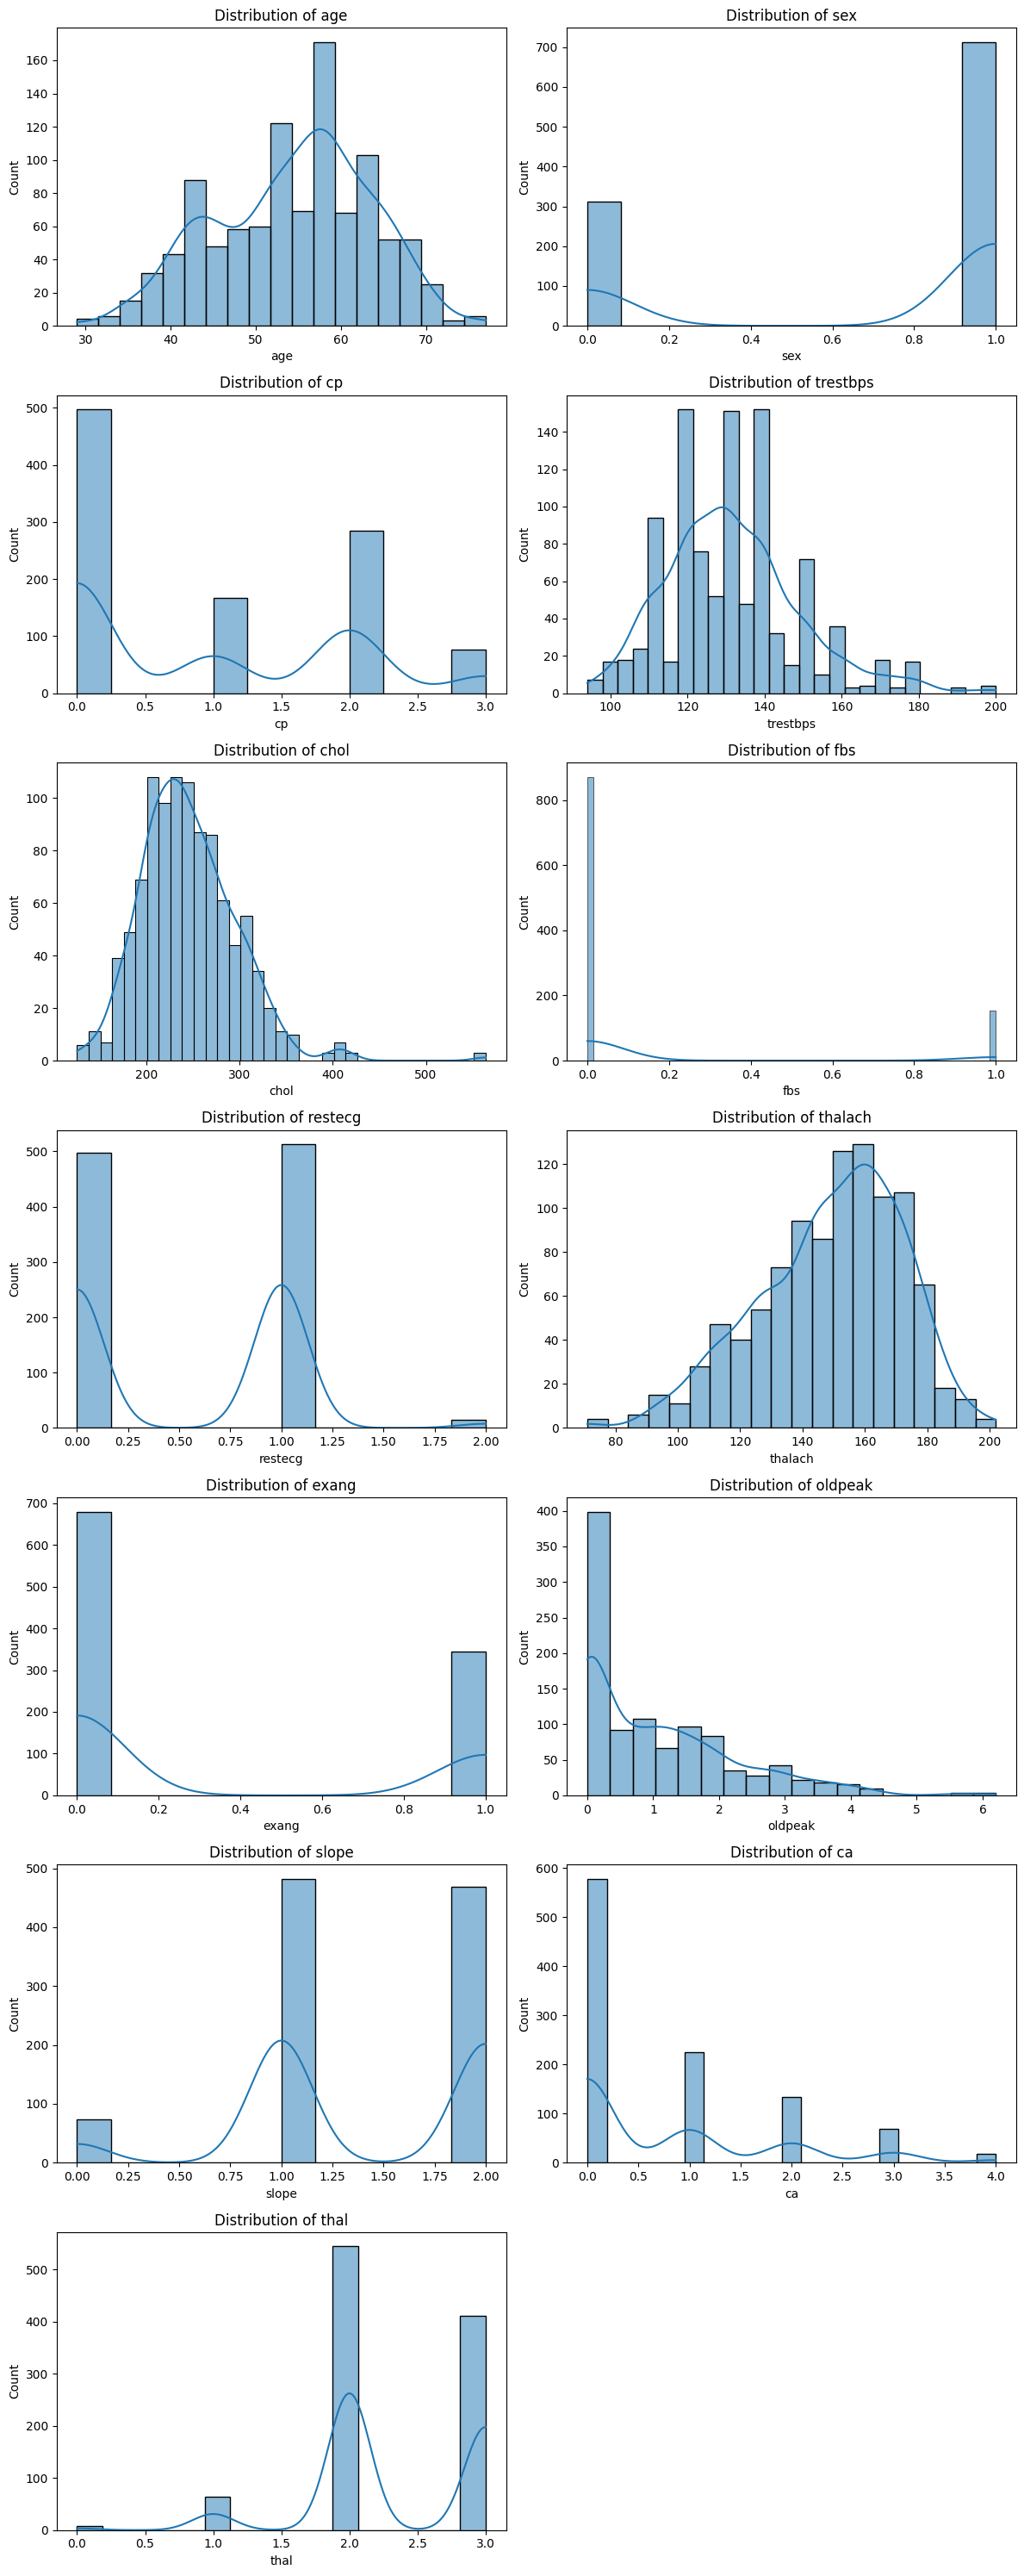

In [102]:
# Data distributions
plt.figure(figsize=(12, 30))
for i, col in enumerate(x.columns, 1):
    plt.subplot(7, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### Data Preprocessing

In [103]:
# fill missing values with mean
df.fillna(df.mean(), inplace=True)

x = x.values
y = y.values

In [104]:
# Standardization of data
def standardize(x):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)

    x = (x - mean) / std
    return x

In [105]:
# One hot encoding
def encode(df):
    df = pd.get_dummies(df, drop_first=True)
    return df

### Model Building

In [106]:
# Split data into train test
def split_dataset(x, y):
    split = int(0.75 * len(x))

    x_train, x_test = x[:split], x[split:]
    y_train, y_test = y[:split], y[split:]

    return x_train, x_test, y_train, y_test

##### Logistic Regression

In [107]:
# sigmoid function 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [108]:
# Brinary Cross-Entropy loss
def loss(y, y_pred):
    m = len(y)
    loss = - (1/(2*m)) * np.sum(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

    return loss

In [109]:
# gradient descent
def train(x, y, alpha=0.01, iters=1000):
    m, n = x.shape
    w, b = np.zeros(n), 0

    for i in range(iters):
        z = np.dot(x, w) + b
        y_pred = sigmoid(z)

        dw = (1/m) * np.dot(x.T, (y_pred - y))
        db = (1/m) * np.sum((y_pred - y))

        w -= alpha*dw
        b -= alpha*db

    return w, b

In [110]:
def predict(x, w, b, th=0.5):
    z = np.dot(x, w) + b
    y_pred = sigmoid(z)

    return (y_pred >= th).astype(int)

In [111]:
x = standardize(x)
df = encode(df)

x_train, x_test, y_train, y_test = split_dataset(x, y)
w, b = train(x_train, y_train)
y_pred = predict(x_test, w, b)
y_pred

array([1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0])

### Model Training Regularization

In [112]:
def train(x, y, alpha=0.01, iters=1000, lambda_=0):
    m, n = x.shape
    w, b = np.zeros(n), 0

    for i in range(iters):
        z = np.dot(x, w) + b
        y_pred = sigmoid(z)

        dw = (1/m) * np.dot(x.T, (y_pred-y)) + lambda_/m*w
        db = (1/m) * np.sum((y_pred - y))

        w -= alpha*dw
        b -= alpha*db

    return w, b

In [113]:
w_l2_1, b_l2_l1 = train(x_train, y_train, lambda_=1)
w_l2_l10, b_l2_l10 = train(x_train, y_train, lambda_=10)

w_l2_l1000, b_l2_l1000 = train(x_train, y_train, lambda_=1000)

y_pred_l1 = predict(x_test, w_l2_1, b_l2_l1)
y_pred_l10 = predict(x_test, w_l2_l10, b_l2_l10)

y_pred_l1000 = predict(x_test, w_l2_l1000, b_l2_l1000)

### Underfitting Experiment
As seen from heat map, the columns with slightly strong correlation are used to train the model:

In [116]:
features = ['cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca']
x_small = df[features].values

x_small = standardize(x_small)
x_train_s, x_test_s, y_train, y_test =  split_dataset(x_small, y)

w_small, b_small = train(x_train_s, y_train)
y_pred_small = predict(x_test_s, w_small, b_small)

### Model Evaluation

In [117]:
def evaluate(y_actual, y_pred):

    TP = np.sum((y_actual==1) & (y_pred==1))
    TN = np.sum((y_actual==0) & (y_pred==0))
    FP = np.sum((y_actual==0) & (y_pred==1))
    FN = np.sum((y_actual==1) & (y_pred==0))

    accuracy = (TP+TN) / (TP+TN+FP+FN)
    precision = (TP) / (TP+FP)
    recall = (TP) / (TP+FN)
    f1_score = (2*precision*recall) / (precision+recall)
    

    formated_str = f"\nAccuracy: {accuracy:.2f}\nPrecision: {precision:.2f}\nRecall: {recall:.2f}\nf1_score: {f1_score:.2f}"
    return formated_str

In [118]:
print("No Regularization: ", evaluate(y_test, y_pred))

No Regularization:  
Accuracy: 0.79
Precision: 0.75
Recall: 0.85
f1_score: 0.80


In [119]:
print("L2 λ=1:", evaluate(y_test, y_pred_l1))

L2 λ=1: 
Accuracy: 0.79
Precision: 0.75
Recall: 0.85
f1_score: 0.80


In [120]:
print("L2 λ=10:", evaluate(y_test, y_pred_l10))

L2 λ=10: 
Accuracy: 0.79
Precision: 0.75
Recall: 0.85
f1_score: 0.80


In [122]:
print("L2 λ=1000:", evaluate(y_test, y_pred_l1000))

L2 λ=1000: 
Accuracy: 0.79
Precision: 0.73
Recall: 0.90
f1_score: 0.80


In [123]:
print("Underfitting Model with related features: ", evaluate(y_test, y_pred_small))

Underfitting Model with related features:  
Accuracy: 0.80
Precision: 0.77
Recall: 0.85
f1_score: 0.80


## Analaysis

##### Full Dataset:
As class is almost balanced, we can rely on accuarcy. And 79% is kinda good.
Recall is high -> that means model catches most heart diseases (target=1) cases
- With Full dataset, there is not overfitting. Its still better.
- Standardization improved the accuracy, as its useful for regularizations.

##### Regularization
- For small lambda 1 and 10 -> no change
- When I changed it to 1000 : Precision decreased and recall increases, as L2 shrinks weights and makes descion boundary smoother so model becomers more conserative

#### Underfitting:
using small dataset, now model have less but more related features -> so this is not underfitting, it reduced model works well (might be underfitting if i had used features those are not co related strongly), so accuarcy and other params imporved.

#### Final Model:
For final model, the model with less features, features who are very less correlated shouldn't be present. It'd be best. 
